SMS DETECTION


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df= pd.read_csv(r"/content/spam.csv", encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)

In [ ]:
df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)

In [ ]:
print(f'Missing Values\n{df.isna().sum()}')
print('Duplicated:', df.duplicated().sum())

Missing Values
target    0
text      0
dtype: int64
Duplicated: 403


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['target']= df['target'].map({'ham': 0, 'spam' : 1})

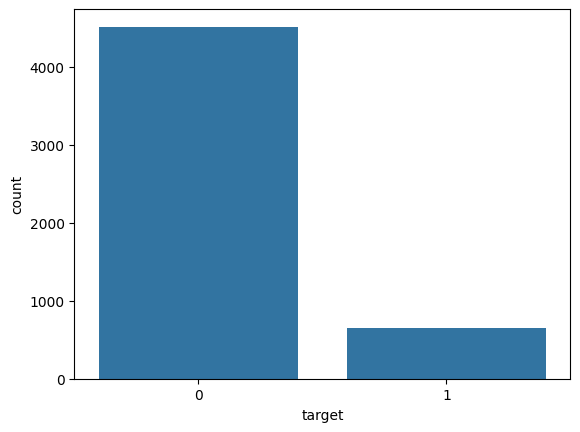

In [ ]:
sns.countplot(df, x= 'target')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
X= df['text']
y = df['target']
X

,text
0,"Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...
3,U dun say so early hor... U c already then say...
4,"Nah I don't think he goes to usf, he lives aro..."
...,...
5567,This is the 2nd time we have tried 2 contact u...
5568,Will Ì_ b going to esplanade fr home?
5569,"Pity, * was in mood for that. So...any other s..."
5570,The guy did some bitching but I acted like i'd...


In [ ]:
y
X_train, X_test, y_train, y_test= train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
lr_pipeline= Pipeline(
    steps=[
        ('preprocessor', TfidfVectorizer(stop_words='english')),
        ('model', LogisticRegression(C=10, penalty='l2', class_weight='balanced'))
    ]
)

In [ ]:
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor', TfidfVectorizer(stop_words='english')),
                ('model', LogisticRegression(C=10, class_weight='balanced'))])

In [ ]:
y_prd_lr= lr_pipeline.predict(X_test)
print('Accuracy', accuracy_score(y_test, y_prd_lr))
print(classification_report(y_test, y_prd_lr))

Accuracy 0.9806576402321083
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       889
           1       0.94      0.92      0.93       145

    accuracy                           0.98      1034
   macro avg       0.96      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034



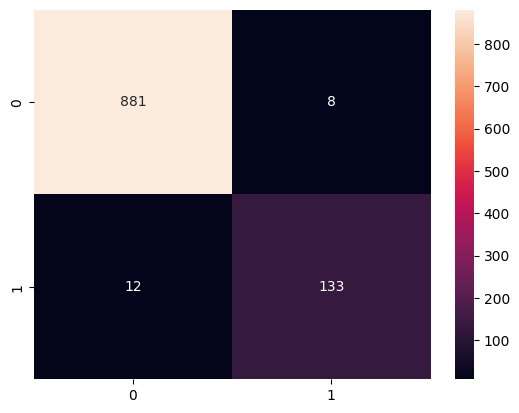

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_prd_lr), annot=True, fmt='d')
plt.show()

In [ ]:
def predict (massage):
    if lr_pipeline.predict([massage]) == 0 :
        return 'Ham'
    return 'Spam'
print(predict('Hello, You have meet in 10 pm'))
print(predict('You win 10000$'))

Ham
Spam


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
tree_pipeline = Pipeline(
    steps=[
        ('preprocessor', TfidfVectorizer(stop_words='english')),
        ('model', DecisionTreeClassifier(max_depth=15, criterion="gini"))
    ]
)
tree_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor', TfidfVectorizer(stop_words='english')),
                ('model', DecisionTreeClassifier(max_depth=15))])

In [ ]:
y_pred_tree= tree_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       889
           1       0.91      0.72      0.80       145

    accuracy                           0.95      1034
   macro avg       0.93      0.85      0.89      1034
weighted avg       0.95      0.95      0.95      1034



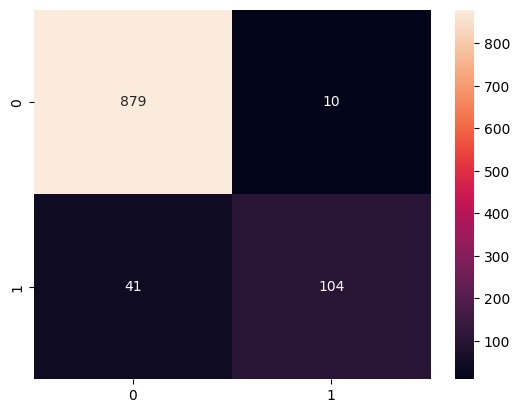

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, fmt='d')
plt.show()


In [ ]:
def predict_tree (massage):
    if tree_pipeline.predict([massage]) == 0 :
        return 'Ham'
    return 'Spam'
print(predict_tree('You won’t believe what happened today 😂'))
print(predict_tree('We attempted to deliver your package today. Reschedule here: www.delivery-support.com'))

Ham
Spam


In [ ]:
this is spam filter model ml project

SyntaxError: invalid syntax (1596789331.py, line 1)